# 🚗 Getaround — Machine Learning · Pricing Optimization

## Contexte
Getaround est la plateforme de location de voitures entre particuliers.
Les propriétaires fixent souvent des prix arbitraires, ce qui crée une perte de revenus ou une perte de compétitivité.

**Objectif** : construire un modèle ML capable de prédire le prix optimal de location journalier
à partir des caractéristiques du véhicule.

## Plan
```
1. EDA & Exploration
2. Preprocessing (Pipeline sklearn)
3. Baseline — Régression Linéaire
4. Modèle final — Gradient Boosting (HistGradientBoostingRegressor)
5. Interprétation des features
6. Sauvegarde du modèle
```

---
## 1. Imports & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

df = pd.read_csv('get_around_pricing_project.csv')
# Supprimer la colonne index inutile
df = df.drop(columns=['Unnamed: 0'])
print(f'Shape : {df.shape}')
df.head()

Shape : (4843, 14)


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


---
## 2. EDA & Exploration

### Variables
- **Cible** : `rental_price_per_day` (prix en €/jour)
- **Numériques** : `mileage`, `engine_power`
- **Catégorielles** : `model_key`, `fuel`, `paint_color`, `car_type`
- **Booléennes** : 7 options (GPS, climatisation, parking...)

In [2]:
print('=== Valeurs manquantes ===')
print(df.isnull().sum())
print()
print('=== Statistiques cible ===')
print(df['rental_price_per_day'].describe())

=== Valeurs manquantes ===
model_key                    0
mileage                      0
engine_power                 0
fuel                         0
paint_color                  0
car_type                     0
private_parking_available    0
has_gps                      0
has_air_conditioning         0
automatic_car                0
has_getaround_connect        0
has_speed_regulator          0
winter_tires                 0
rental_price_per_day         0
dtype: int64

=== Statistiques cible ===
count    4843.000000
mean      121.214536
std        33.568268
min        10.000000
25%       104.000000
50%       119.000000
75%       136.000000
max       422.000000
Name: rental_price_per_day, dtype: float64


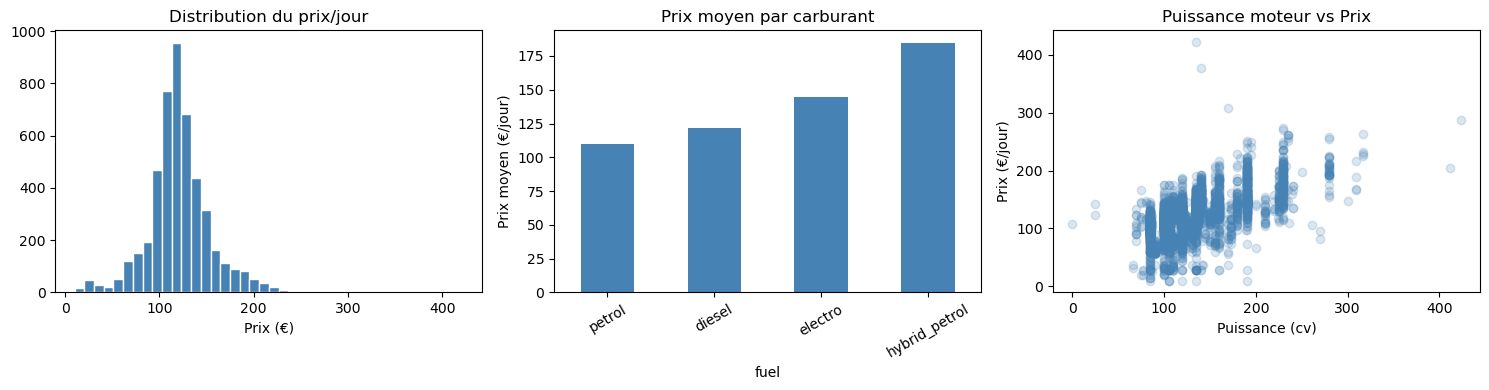

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution du prix
axes[0].hist(df['rental_price_per_day'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du prix/jour')
axes[0].set_xlabel('Prix (€)')

# Prix par type de carburant
df.groupby('fuel')['rental_price_per_day'].mean().sort_values().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Prix moyen par carburant')
axes[1].set_ylabel('Prix moyen (€/jour)')
axes[1].tick_params(axis='x', rotation=30)

# Puissance vs prix
axes[2].scatter(df['engine_power'], df['rental_price_per_day'], alpha=0.2, color='steelblue')
axes[2].set_title('Puissance moteur vs Prix')
axes[2].set_xlabel('Puissance (cv)')
axes[2].set_ylabel('Prix (€/jour)')

plt.tight_layout()
plt.show()

**📌 Observations EDA** :
- Prix moyen ~121 €/jour, médiane ~119 € — distribution légèrement asymétrique à droite
- La puissance moteur est positivement corrélée au prix — feature très informative
- Les véhicules électriques ont un prix moyen supérieur aux thermiques
- Aucune valeur manquante — pas d'imputation nécessaire
- `Unnamed: 0` est un index numérique sans valeur prédictive → supprimé

---
## 3. Preprocessing (Pipeline sklearn)

In [5]:
TARGET = 'rental_price_per_day'

# Features selon leur type — détermine le transformer à appliquer
NUM_FEATURES  = ['mileage', 'engine_power']                    # → StandardScaler
CAT_FEATURES  = ['model_key', 'fuel', 'paint_color', 'car_type']  # → OneHotEncoder
BOOL_FEATURES = [
    'private_parking_available', 'has_gps', 'has_air_conditioning',
    'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires'
]  # → passthrough (déjà 0/1)

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + BOOL_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')

# ColumnTransformer : applique le bon transformer à chaque groupe
preprocessor = ColumnTransformer(transformers=[
    ('num',  StandardScaler(),                                            NUM_FEATURES),
    ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
    ('bool', 'passthrough',                                               BOOL_FEATURES),
])

print('Pipeline défini')

Train : 3874 lignes | Test : 969 lignes
Pipeline défini


**📌 Choix de preprocessing** :
- **StandardScaler** sur mileage/engine_power : échelles très différentes (0-300 000 km vs 50-500 cv) — sans normalisation le modèle linéaire traite les unités de façon incohérente
- **OneHotEncoder** sur les catégorielles : `model_key='Renault'` n'est pas ordinalement supérieur à `model_key='BMW'` — chaque modalité devient une colonne binaire indépendante
- **passthrough** sur les booléennes : déjà en 0/1, aucune transformation nécessaire
- `Unnamed: 0` supprimé en amont : c'est un index sans valeur prédictive — le laisser créerait du bruit

---
## 4. Modèle Baseline — Régression Linéaire

In [6]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test  = lr_model.predict(X_test)

print('=== BASELINE — Régression Linéaire ===')
print(f'TRAIN : R²={r2_score(y_train, y_pred_lr_train):.3f} | MAE={mean_absolute_error(y_train, y_pred_lr_train):.1f} €')
print(f'TEST  : R²={r2_score(y_test,  y_pred_lr_test ):.3f} | MAE={mean_absolute_error(y_test,  y_pred_lr_test ):.1f} €')

=== BASELINE — Régression Linéaire ===
TRAIN : R²=0.714 | MAE=12.1 €
TEST  : R²=0.694 | MAE=12.1 €


**📌 Interprétation baseline** :
- R² test 0.694 → le modèle explique 69% de la variance du prix
- MAE 12.1€ → en moyenne l'erreur est de 12€/jour
- Léger écart train/test → overfitting modéré, acceptable pour un modèle linéaire
- Ces performances constituent notre **référence** — le modèle suivant doit faire mieux

---
## 5. Modèle Final — Gradient Boosting (HistGradientBoostingRegressor)

Le **Gradient Boosting** construit des arbres de décision séquentiellement : chaque arbre corrige les erreurs du précédent.
`HistGradientBoosting` est la version optimisée sklearn (similaire à XGBoost/LightGBM) — rapide et performante sur des datasets tabulaires.

In [7]:
gbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

gbm_model.fit(X_train, y_train)

y_pred_gbm_train = gbm_model.predict(X_train)
y_pred_gbm_test  = gbm_model.predict(X_test)

print('=== Gradient Boosting ===')
print(f'TRAIN : R²={r2_score(y_train, y_pred_gbm_train):.3f} | MAE={mean_absolute_error(y_train, y_pred_gbm_train):.1f} €')
print(f'TEST  : R²={r2_score(y_test,  y_pred_gbm_test ):.3f} | MAE={mean_absolute_error(y_test,  y_pred_gbm_test ):.1f} €')

=== Gradient Boosting ===
TRAIN : R²=0.841 | MAE=8.7 €
TEST  : R²=0.743 | MAE=10.7 €


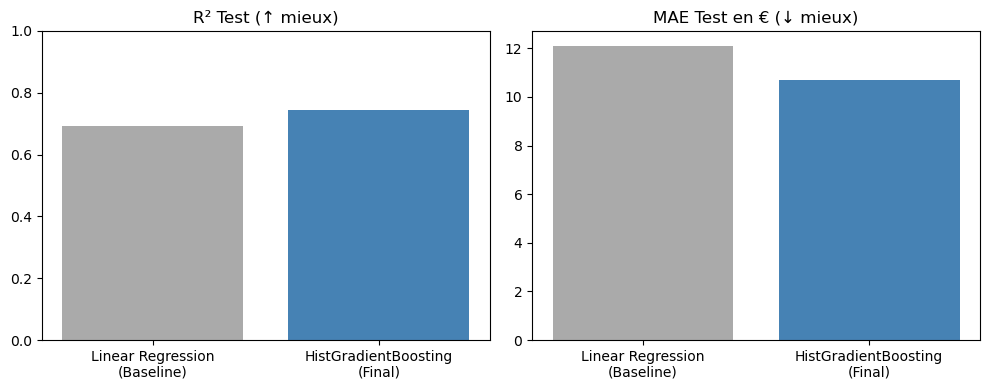


Gain R² : +0.049
Gain MAE : -1.4 €


In [8]:
# Comparaison visuelle
models  = ['Linear Regression\n(Baseline)', 'HistGradientBoosting\n(Final)']
r2_vals = [r2_score(y_test, y_pred_lr_test), r2_score(y_test, y_pred_gbm_test)]
mae_vals= [mean_absolute_error(y_test, y_pred_lr_test), mean_absolute_error(y_test, y_pred_gbm_test)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(models, r2_vals, color=['#aaa','steelblue'])
axes[0].set_title('R² Test (↑ mieux)')
axes[0].set_ylim(0, 1)
axes[1].bar(models, mae_vals, color=['#aaa','steelblue'])
axes[1].set_title('MAE Test en € (↓ mieux)')
plt.tight_layout()
plt.show()

print(f'\nGain R² : +{(r2_vals[1]-r2_vals[0]):.3f}')
print(f'Gain MAE : -{(mae_vals[0]-mae_vals[1]):.1f} €')

**📌 Interprétation Gradient Boosting** :
- R² test 0.743 vs 0.694 baseline → **+5 points de R²**
- MAE ~10.7€ vs 12.1€ baseline → **-1.4€ d'erreur moyenne**
- Le GBM capture les non-linéarités (ex: un SUV électrique avec GPS a un prix qui ne s'explique pas par une simple somme linéaire)
- `max_depth=5` limite la profondeur des arbres → contrôle l'overfitting
- `learning_rate=0.1` : chaque arbre corrige 10% des erreurs → convergence stable

---
## 6. Sauvegarde & Conclusion

| Modèle | R² Train | R² Test | MAE Test |
|---|---|---|---|
| Régression Linéaire (baseline) | 0.714 | 0.694 | 12.1 € |
| **HistGradientBoosting (final)** | **0.841** | **0.743** | **10.7 €** |

**Modèle retenu** : HistGradientBoostingRegressor — meilleur R² et MAE sur le test set.

Le modèle est déployé via FastAPI sur Hugging Face Spaces.

In [11]:
import joblib
import pandas as pd

# ── Sauvegarde ────────────────────────────────────────────────────────────────
joblib.dump(gbm_model, 'pricing_model.joblib')
print(' Modèle sauvegardé : pricing_model.joblib')

# ── Test de prédiction ────────────────────────────────────────────────────────
NUM_FEATURES  = ['mileage', 'engine_power']
CAT_FEATURES  = ['model_key', 'fuel', 'paint_color', 'car_type']
BOOL_FEATURES = [
    'private_parking_available', 'has_gps', 'has_air_conditioning',
    'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires'
]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + BOOL_FEATURES

test_car = pd.DataFrame([[
    80000, 120,                          # num
    'Renault', 'diesel', 'black', 'sedan',  # cat
    True, True, True, False, True, True, False  # bool
]], columns=ALL_FEATURES)

pred = gbm_model.predict(test_car)[0]
print(f' Test — Renault diesel 80 000km 120cv : {pred:.0f} €/jour')

 Modèle sauvegardé : pricing_model.joblib
 Test — Renault diesel 80 000km 120cv : 142 €/jour
